## Notebook 5 of 5: Evaluating the trained classifiers

1. [`01_overview_and_vep.ipynb`](./01_overview_and_vep.ipynb) -- setup, family-aware
   train/test split, gene/ontology descriptions, AlphaGenome reference-only overview plots,
   classical Variant Effect Prediction (VEP).
2. [`02_individual_predictions.ipynb`](./02_individual_predictions.ipynb) -- per-individual
   consensus RNA-seq, comparing two individuals, bulk prediction generation.
3. [`03_population_analysis.ipynb`](./03_population_analysis.ipynb) -- population-level
   comparison, MANE-exon restriction, single-ontology restriction, significance test.
4. [`04_modeling.ipynb`](./04_modeling.ipynb) -- trains a LogisticRegression classifier on
   MANE-exon-restricted features, a second on whole-gene-span features, and a tiny torch MLP
   on the full concatenated signal; persists all three to `notebooks/.cache/models/`.
5. [`05_evaluation.ipynb`](./05_evaluation.ipynb) -- loads the persisted models, evaluates them
   on the held-out test split, reference/variant label prediction, literature-vs-background
   variant comparison.

**This is notebook 5.** It loads `mane_exon_model`, `gene_span_model`, `nn_model`, `nn_scaler`,
and the held-out test features notebook 4 persisted to `notebooks/.cache/models/` -- no model
fitting or `notebooks/.cache/predictions/` reads happen here. The reference-genome/variant
prediction and literature-vs-background comparison sections at the end make fresh AlphaGenome
API calls, so `ALPHAGENOME_API_KEY` is still needed to run this notebook end to end.


In [1]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

REPO_ROOT = Path("/home/breno/I2CA/genomics")
NOTEBOOK_DIR = REPO_ROOT / "notebooks"
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))
os.chdir(NOTEBOOK_DIR)

from utils import setup, rna_features
from utils import predictions as predictions_utils
from utils import models as models_utils
from alphagenome.data import genome
from alphagenome.models import dna_client

ctx = setup.load_experiment(NOTEBOOK_DIR)
GENES, ONTOLOGY_TERMS, CLASS_MAP = ctx.GENES, ctx.ONTOLOGY_TERMS, ctx.CLASS_MAP
gene_rows, individuals, samples_by_class = ctx.gene_rows, ctx.individuals, ctx.samples_by_class
windows_df, gtf = ctx.windows_df, ctx.gtf
PREDICTIONS_CACHE_DIR = ctx.PREDICTIONS_CACHE_DIR
REFERENCE_PREDICTIONS_CACHE_DIR = ctx.REFERENCE_PREDICTIONS_CACHE_DIR

train_samples_by_class, test_samples_by_class = setup.get_train_test_split(individuals, CLASS_MAP)

# Only the reference-genome/variant prediction section further down makes fresh AlphaGenome API
# calls (predict_reference_interval is cached per gene, predict_variant_effect is not) -- the
# evaluation sections above it only read notebooks/.cache/models/ (built by notebook 4).
client, ORGANISM = setup.create_client()
print("AlphaGenome client ready.")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

MODELS_CACHE_DIR = NOTEBOOK_DIR / ".cache" / "models"
metadata = models_utils.load_metadata(MODELS_CACHE_DIR / "model_metadata.json")
assert metadata["GENES"] == GENES, "notebook 4's GENES order must match this notebook's"
significant_genes = metadata["significant_genes"]
gene_widths = metadata["gene_widths"]
gene_offsets = metadata["gene_offsets"]
feature_dim = metadata["feature_dim"]
MODEL_ONTOLOGY_TERMS = metadata["MODEL_ONTOLOGY_TERMS"]

gene_zoom_slices = rna_features.compute_gene_zoom_slices(gtf, GENES, dna_client.SEQUENCE_LENGTH_500KB)

mane_exon_model = models_utils.load_sklearn_model(MODELS_CACHE_DIR / "mane_exon_model.joblib")
gene_span_model = models_utils.load_sklearn_model(MODELS_CACHE_DIR / "gene_span_model.joblib")
nn_scaler = models_utils.load_sklearn_model(MODELS_CACHE_DIR / "nn_scaler.joblib")
nn_model = models_utils.load_nn_model(
    MODELS_CACHE_DIR / "nn_model_state_dict.pt",
    input_dim=feature_dim,
    hidden_dim=metadata["nn_hidden_dim"],
    device=device,
)
print("Loaded mane_exon_model, gene_span_model, nn_model, nn_scaler from", MODELS_CACHE_DIR)

test_features_df = pd.read_csv(MODELS_CACHE_DIR / "test_features_mane_exon.csv")
test_gene_features_df = pd.read_csv(MODELS_CACHE_DIR / "test_features_gene_span.csv")
_nn_test = np.load(MODELS_CACHE_DIR / "test_features_nn.npz")
X_test_nn, y_test_nn, nn_test_ids = _nn_test["X"], _nn_test["y"], _nn_test["sample_ids"]

X_test = test_features_df[significant_genes].values
y_test = (test_features_df["label"] == "strong pigmentation").to_numpy(dtype=int)
X_test_gene = test_gene_features_df[significant_genes].values
y_test_gene = (test_gene_features_df["label"] == "strong pigmentation").to_numpy(dtype=int)

print(f"Test-split sizes: mane-exon {X_test.shape}, gene-span {X_test_gene.shape}, NN {X_test_nn.shape}")


/home/breno/miniforge3/envs/genomics/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AlphaGenome client ready.
Using device: cuda


Loaded mane_exon_model, gene_span_model, nn_model, nn_scaler from /home/breno/I2CA/genomics/notebooks/.cache/models


Test-split sizes: mane-exon (210, 9), gene-span (210, 9), NN (210, 1010926)


## Evaluating `mane_exon_model` (LogisticRegression, MANE-exon log-means)

Held-out accuracy/ROC-AUC/confusion matrix/classification report for the classifier notebook 4
fit on MANE-exon-restricted, log-transformed per-gene means -- the same `X_test`/`y_test` split
notebook 4 built and persisted, so these numbers reproduce exactly what notebook 4 would have
printed inline, without needing its kernel state.


In [2]:
y_pred = mane_exon_model.predict(X_test)
y_proba = mane_exon_model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba):.3f}")
print("\nConfusion matrix (rows=true, cols=pred; 0=weak, 1=strong):")
print(confusion_matrix(y_test, y_pred))
print("\n" + classification_report(y_test, y_pred, target_names=["weak pigmentation", "strong pigmentation"]))

coef_df = pd.DataFrame({
    "gene": significant_genes,
    "coefficient": mane_exon_model.named_steps["logisticregression"].coef_[0],
}).sort_values("coefficient", key=abs, ascending=False).reset_index(drop=True)

# Sign of each gene's own coefficient -- reused below to derive a "pro-pigmentation" vs
# "anti-pigmentation" phenotype-direction label for literature variants (see the markdown
# section further down).
gene_coefficient_sign = dict(zip(significant_genes, mane_exon_model.named_steps["logisticregression"].coef_[0]))

coef_df


Accuracy: 0.833
ROC-AUC : 0.925

Confusion matrix (rows=true, cols=pred; 0=weak, 1=strong):
[[ 61  16]
 [ 19 114]]

                     precision    recall  f1-score   support

  weak pigmentation       0.76      0.79      0.78        77
strong pigmentation       0.88      0.86      0.87       133

           accuracy                           0.83       210
          macro avg       0.82      0.82      0.82       210
       weighted avg       0.83      0.83      0.83       210



,gene,coefficient
0,TYR,-1.067406
1,MFSD12,-1.038473
2,MC1R,1.000984
3,KITLG,-0.945232
4,TYRP1,-0.922219
5,SLC45A2,-0.502436
6,SLC24A5,0.195211
7,DDB1,-0.190224
8,HERC2,0.166767


## Evaluating `gene_span_model` (LogisticRegression, whole-gene log-means)

Same evaluation, for the follow-up classifier fit on whole-gene-span (not just MANE-exon) means.


In [3]:
y_pred_gene = gene_span_model.predict(X_test_gene)
y_proba_gene = gene_span_model.predict_proba(X_test_gene)[:, 1]

print(f"Accuracy: {accuracy_score(y_test_gene, y_pred_gene):.3f}")
print(f"ROC-AUC : {roc_auc_score(y_test_gene, y_proba_gene):.3f}")
print("\nConfusion matrix (rows=true, cols=pred; 0=weak, 1=strong):")
print(confusion_matrix(y_test_gene, y_pred_gene))
print("\n" + classification_report(y_test_gene, y_pred_gene, target_names=["weak pigmentation", "strong pigmentation"]))

gene_span_coef_df = pd.DataFrame({
    "gene": significant_genes,
    "coefficient": gene_span_model.named_steps["logisticregression"].coef_[0],
}).sort_values("coefficient", key=abs, ascending=False).reset_index(drop=True)
gene_span_coef_df


Accuracy: 0.895
ROC-AUC : 0.965

Confusion matrix (rows=true, cols=pred; 0=weak, 1=strong):
[[ 64  13]
 [  9 124]]

                     precision    recall  f1-score   support

  weak pigmentation       0.88      0.83      0.85        77
strong pigmentation       0.91      0.93      0.92       133

           accuracy                           0.90       210
          macro avg       0.89      0.88      0.89       210
       weighted avg       0.89      0.90      0.89       210



,gene,coefficient
0,MFSD12,-2.158514
1,MC1R,1.267669
2,TYR,-0.925087
3,TYRP1,-0.859465
4,KITLG,-0.672504
5,SLC24A5,0.609410
6,SLC45A2,-0.523280
7,DDB1,-0.180717
8,HERC2,0.172833


## Evaluating `nn_model` (tiny MLP, full concatenated signal)

Same evaluation, for the tiny MLP fit on the full ~950k-dimensional concatenated per-position
signal across all 11 genes. Recall the heavy-overfitting caveat from notebook 4: this is a
`p >> n` regime (~860 train individuals vs. ~950k features), so treat these held-out numbers as
a rough sanity check, not a tuned result.


In [4]:
y_test_nn_int = y_test_nn.astype(int)
X_test_t = torch.from_numpy(X_test_nn).to(device)

nn_model.eval()
with torch.no_grad():
    test_proba = torch.sigmoid(nn_model(X_test_t)).cpu().numpy()
test_pred = (test_proba > 0.5).astype(int)

print(f"Accuracy: {accuracy_score(y_test_nn_int, test_pred):.3f}")
print(f"ROC-AUC : {roc_auc_score(y_test_nn_int, test_proba):.3f}")
print("\nConfusion matrix (rows=true, cols=pred; 0=weak, 1=strong):")
print(confusion_matrix(y_test_nn_int, test_pred))
print("\n" + classification_report(y_test_nn_int, test_pred, target_names=["weak pigmentation", "strong pigmentation"]))


Accuracy: 0.990
ROC-AUC : 0.992

Confusion matrix (rows=true, cols=pred; 0=weak, 1=strong):
[[ 77   0]
 [  2 131]]



                     precision    recall  f1-score   support

  weak pigmentation       0.97      1.00      0.99        77
strong pigmentation       1.00      0.98      0.99       133

           accuracy                           0.99       210
          macro avg       0.99      0.99      0.99       210
       weighted avg       0.99      0.99      0.99       210



## Predicting a label for the reference genome, and for every gene's literature variants

Baseline: predict a label for the unmodified reference genome using `nn_model` (every gene
at its own reference-genome signal). Every literature-variant analysis below measures a
*shift* from this baseline when one gene's signal is swapped for its ALT-allele prediction.


In [5]:
VARIANT_ONTOLOGY_TERMS = MODEL_ONTOLOGY_TERMS  # keep this consistent with the models above


def reference_gene_span_signal(gene: str) -> np.ndarray:
    """Reference-genome analog of individual_gene_span_signal: AlphaGenome's prediction on the
    unmodified reference sequence, strand-filtered, restricted to MODEL_ONTOLOGY_TERMS, cropped
    to the gene's own GTF span, then doubled to approximate a homozygous-reference individual
    (every trained feature was an H1+H2 *sum*, so a single reference haplotype alone would sit
    at half that scale)."""
    gene_data = windows_df.loc[windows_df["gene"] == gene].iloc[0]
    interval = genome.Interval(gene_data["chrom"], gene_data["start"], gene_data["end"])
    strand = rna_features.gene_strand(gtf, gene)
    lo, hi = gene_zoom_slices[gene]

    track = predictions_utils.predict_reference_interval(
        client,
        gene=gene,
        interval=interval,
        requested_outputs=[dna_client.OutputType.RNA_SEQ],
        ontology_terms=VARIANT_ONTOLOGY_TERMS,
        cache_dir=REFERENCE_PREDICTIONS_CACHE_DIR,
    )
    track = track.filter_to_positive_strand() if strand == "+" else track.filter_to_negative_strand()
    return 2 * track.values.sum(axis=1)[lo:hi].astype(np.float32)


def build_reference_feature_vector(override_gene: str = None, override_signal: np.ndarray = None) -> np.ndarray:
    """Concatenates every gene's (doubled) reference-genome signal, in the same GENES order /
    offsets used to build X_train_nn/X_test_nn -- optionally swapping in a precomputed signal
    (e.g. a doubled ALT-allele prediction) for one gene."""
    x = np.empty(feature_dim, dtype=np.float32)
    for gene in GENES:
        offset, width = gene_offsets[gene], gene_widths[gene]
        x[offset:offset + width] = (
            override_signal if gene == override_gene else reference_gene_span_signal(gene)
        )
    return x


def predict_label(x: np.ndarray) -> tuple:
    x_scaled = nn_scaler.transform(x.reshape(1, -1)).astype(np.float32)
    nn_model.eval()
    with torch.no_grad():
        proba = torch.sigmoid(nn_model(torch.from_numpy(x_scaled).to(device))).item()
    return ("strong pigmentation" if proba > 0.5 else "weak pigmentation"), proba


x_ref = build_reference_feature_vector()
ref_label, ref_proba = predict_label(x_ref)
print(f"Reference genome -> predicted label: {ref_label} (P[strong pigmentation]={ref_proba:.3f})")


Reference genome -> predicted label: weak pigmentation (P[strong pigmentation]=0.000)


## Does a variant's predicted effect land on the phenotype-expected side? (pro- vs. anti-pigmentation, all genes)

**The problem this section answers**: GTEx only tells us a variant's effect on *gene expression*
(the `direction` column: "enhance" raises expression, "diminish" lowers it) -- not whether that's
expected to increase or decrease *pigmentation itself*. Whether "more expression of gene G" means
"more pigmented" depends on G's biological role, and that relationship isn't uniform across the
panel (e.g. ASIP is an MC1R antagonist, so higher ASIP expression is expected to *reduce*
pigmentation -- the opposite sign convention from most other genes here).

**Method**: rather than hand-curating a per-gene "does more expression mean more pigmentation"
table (error-prone, and exactly the kind of manual judgment call this notebook series has been
moving away from), each gene's sign convention is read directly off `mane_exon_model`'s own
trained coefficient for that gene (`gene_coefficient_sign`, computed above from `coef_df`): a
positive coefficient means this study's own data already associates higher expression of that
gene with the "strong pigmentation" class; negative means the opposite. A literature variant is
then labeled:

- **pro-pigmentation**: its GTEx expression-direction points the same way this gene's expression
  already points toward "strong pigmentation" in the trained model (`enhance` + positive
  coefficient, or `diminish` + negative coefficient).
- **anti-pigmentation**: the opposite combination.

See `literature_variants.add_phenotype_direction()` for the exact logic.

**Important caveat**: this makes the check *partially circular* for `mane_exon_model`'s own logit,
since `gene_coefficient_sign` is drawn from that exact model -- a "correct-side" result there
partly just confirms internal consistency, not independent validation. It is **not** circular for
`score_variants`'s raw_score (a model-independent, purely AlphaGenome-native quantity) or for
`gene_span_model`/`nn_model` (different features, and for the NN a different architecture
entirely, than the one the sign convention came from) -- agreement in those three is the
genuinely informative signal.

Rain plots below are generated for every gene with a valid `mane_exon_model` coefficient (i.e.
every gene in `significant_genes`) -- a gene without one has no defined sign convention to derive
`phenotype_direction` from, so it's skipped.


In [6]:
def reference_gene_scalar_features(gene: str) -> dict:
    """Reference-genome (doubled) MANE-exon and whole-gene-span log-means for one gene -- the
    baseline the two LogisticRegression models use for every gene except the one variant/gene
    combination under test at any given time."""
    gene_data = windows_df.loc[windows_df["gene"] == gene].iloc[0]
    interval = genome.Interval(gene_data["chrom"], gene_data["start"], gene_data["end"])
    strand = rna_features.gene_strand(gtf, gene)
    window_size = gene_data["end"] - gene_data["start"]
    lo, hi = gene_zoom_slices[gene]
    mask = rna_features.mane_exon_mask(gtf, gene, gene_data["start"], window_size)

    track = predictions_utils.predict_reference_interval(
        client,
        gene=gene,
        interval=interval,
        requested_outputs=[dna_client.OutputType.RNA_SEQ],
        ontology_terms=VARIANT_ONTOLOGY_TERMS,
        cache_dir=REFERENCE_PREDICTIONS_CACHE_DIR,
    )
    track = track.filter_to_positive_strand() if strand == "+" else track.filter_to_negative_strand()
    full_signal = 2 * track.values.sum(axis=1).astype(np.float32)
    return {
        "mane_exon_log_mean": np.log(full_signal[mask].mean() + 0.001),
        "gene_span_log_mean": np.log(full_signal[lo:hi].mean() + 0.001),
    }


reference_scalar_by_gene = {gene: reference_gene_scalar_features(gene) for gene in significant_genes}

# Reference-genome (GRCh38, every gene at baseline) logit for each model -- the fixed point every
# alt-allele logit below is measured against, so rain plots show delta-logit (alt - reference)
# instead of an absolute logit whose zero point has no direct biological meaning.
ref_mane_exon_row = np.array([[reference_scalar_by_gene[g]["mane_exon_log_mean"] for g in significant_genes]])
ref_gene_span_row = np.array([[reference_scalar_by_gene[g]["gene_span_log_mean"] for g in significant_genes]])
ref_mane_exon_logit = mane_exon_model.decision_function(ref_mane_exon_row)[0]
ref_gene_span_logit = gene_span_model.decision_function(ref_gene_span_row)[0]

x_ref_scaled = nn_scaler.transform(x_ref.reshape(1, -1)).astype(np.float32)
nn_model.eval()
with torch.no_grad():
    ref_nn_logit = nn_model(torch.from_numpy(x_ref_scaled).to(device)).item()

print(f"Reference-genome logits: mane_exon={ref_mane_exon_logit:.3f}, "
      f"gene_span={ref_gene_span_logit:.3f}, nn={ref_nn_logit:.3f}")


Reference-genome logits: mane_exon=-3.736, gene_span=-4.393, nn=-1588.655


In [7]:
from utils import data as data_utils
from alphagenome.models import variant_scorers

rna_scorer = variant_scorers.RECOMMENDED_VARIANT_SCORERS["RNA_SEQ"]


def score_variants_rna(variants_list: list, gene: str) -> pd.DataFrame:
    """RNA_SEQ score_variants for a batch of variants, tidied and restricted to `gene`'s
    melanocyte-of-skin track."""
    intervals = [v.reference_interval.resize(dna_client.SEQUENCE_LENGTH_500KB) for v in variants_list]
    raw = client.score_variants(
        intervals=intervals, variants=variants_list, variant_scorers=[rna_scorer], max_workers=2
    )
    tidy = variant_scorers.tidy_scores(raw, match_gene_strand=True)
    return tidy[(tidy["gene_name"] == gene) & (tidy["ontology_curie"] == ONTOLOGY_TERMS[0])].copy()


_gene_alt_signal_cache: dict = {}  # (gene, variant_str) -> doubled full-window ALT signal


def gene_alt_signal(gene: str, variant_str: str) -> np.ndarray:
    """Fetches (and caches in-session) `gene`'s doubled full-window ALT signal for one variant --
    one fresh predict_variant_effect API call per distinct (gene, variant) pair."""
    key = (gene, variant_str)
    if key not in _gene_alt_signal_cache:
        gene_data = windows_df.loc[windows_df["gene"] == gene].iloc[0]
        interval = genome.Interval(gene_data["chrom"], gene_data["start"], gene_data["end"])
        strand = rna_features.gene_strand(gtf, gene)
        _, alt_track = predictions_utils.predict_variant_effect(
            client,
            gene=gene,
            interval=interval,
            variant=genome.Variant.from_str(variant_str),
            requested_outputs=[dna_client.OutputType.RNA_SEQ],
            ontology_terms=VARIANT_ONTOLOGY_TERMS,
        )
        alt_track = alt_track.filter_to_positive_strand() if strand == "+" else alt_track.filter_to_negative_strand()
        _gene_alt_signal_cache[key] = 2 * alt_track.values.sum(axis=1).astype(np.float32)
    return _gene_alt_signal_cache[key]


def model_logits_for_variant(gene: str, variant_str: str) -> dict:
    """One ALT signal for (gene, variant) reused three ways: a MANE-exon log-mean for
    mane_exon_model, a whole-gene-span log-mean for gene_span_model, and the raw per-position
    span for nn_model -- every other gene stays at its reference baseline. Returns delta-logit
    (this variant's logit minus the reference-genome logit for that same model), not the raw
    logit -- the meaningful zero point is "same as reference," not "same as decision boundary."
    """
    gene_data = windows_df.loc[windows_df["gene"] == gene].iloc[0]
    window_size = gene_data["end"] - gene_data["start"]
    mask = rna_features.mane_exon_mask(gtf, gene, gene_data["start"], window_size)
    lo, hi = gene_zoom_slices[gene]

    full_signal = gene_alt_signal(gene, variant_str)
    mane_exon_log_mean = np.log(full_signal[mask].mean() + 0.001)
    gene_span_log_mean = np.log(full_signal[lo:hi].mean() + 0.001)

    mane_exon_row = np.array([[
        mane_exon_log_mean if g == gene else reference_scalar_by_gene[g]["mane_exon_log_mean"]
        for g in significant_genes
    ]])
    gene_span_row = np.array([[
        gene_span_log_mean if g == gene else reference_scalar_by_gene[g]["gene_span_log_mean"]
        for g in significant_genes
    ]])

    x_nn = build_reference_feature_vector(override_gene=gene, override_signal=full_signal[lo:hi])
    x_nn_scaled = nn_scaler.transform(x_nn.reshape(1, -1)).astype(np.float32)
    nn_model.eval()
    with torch.no_grad():
        nn_logit = nn_model(torch.from_numpy(x_nn_scaled).to(device)).item()

    return {
        "mane_exon_delta_logit": mane_exon_model.decision_function(mane_exon_row)[0] - ref_mane_exon_logit,
        "gene_span_delta_logit": gene_span_model.decision_function(gene_span_row)[0] - ref_gene_span_logit,
        "nn_delta_logit": nn_logit - ref_nn_logit,
    }


In [8]:
from utils import literature_variants

GENES_FOR_RAIN_PLOTS = significant_genes  # only genes with a valid mane_exon_model coefficient

rain_plot_results = {}  # gene -> {"lit_score": df, "bg_score": df, "logit_df": df, "bg_logit_df": df}

# TOP_N_LITERATURE_VARIANTS_PER_GENE = literature_variants.DEFAULT_TOP_N
TOP_N_LITERATURE_VARIANTS_PER_GENE = 100

for gene in GENES_FOR_RAIN_PLOTS:
    t0 = time.time()
    lit_df = literature_variants.get_literature_variants(
        gene, windows_df, ctx.ANNOTATIONS_CACHE_DIR, top_n=TOP_N_LITERATURE_VARIANTS_PER_GENE,
    )
    if lit_df.empty:
        print(f"{gene}: no GTEx skin-eQTL literature variants in window, skipping.")
        continue
    lit_df = literature_variants.add_phenotype_direction(lit_df, gene_coefficient_sign[gene])

    _, gene_vcf_path = data_utils.gene_paths(gene)
    lit_positions = {genome.Variant.from_str(v).position for v in lit_df["variant"]}
    background_variants = data_utils.sample_background_variants_from_vcf(
        gene_vcf_path, exclude_positions=lit_positions, min_allele_frequency=0.01, n=30,
    )
    bg_variant_strs = [
        f"{v.chromosome}:{v.position}:{v.reference_bases}>{v.alternate_bases}" for v in background_variants
    ]

    lit_variant_objs = [genome.Variant.from_str(v) for v in lit_df["variant"]]
    lit_score = score_variants_rna(lit_variant_objs, gene)
    lit_score["variant_str"] = lit_score["variant_id"].map(
        lambda v: f"{v.chromosome}:{v.position}:{v.reference_bases}>{v.alternate_bases}"
    )
    lit_score = lit_score.merge(
        lit_df[["variant", "phenotype_direction"]], left_on="variant_str", right_on="variant", how="left"
    )

    bg_score = score_variants_rna(background_variants, gene)

    logit_rows = [
        {"variant": variant_str, "phenotype_direction": phenotype_direction, **model_logits_for_variant(gene, variant_str)}
        for variant_str, phenotype_direction in zip(lit_df["variant"], lit_df["phenotype_direction"])
    ]
    logit_df = pd.DataFrame(logit_rows)

    # Same 3-model logits for the background variants -- needed so mane_exon_logit/gene_span_logit/
    # nn_logit panels can show a background comparison too, not just the score_variants raw_score panel.
    bg_logit_rows = [
        {"variant": variant_str, **model_logits_for_variant(gene, variant_str)}
        for variant_str in bg_variant_strs
    ]
    bg_logit_df = pd.DataFrame(bg_logit_rows)

    rain_plot_results[gene] = {
        "lit_score": lit_score, "bg_score": bg_score, "logit_df": logit_df, "bg_logit_df": bg_logit_df,
    }
    n_pro = (lit_df["phenotype_direction"] == "pro-pigmentation").sum()
    n_anti = (lit_df["phenotype_direction"] == "anti-pigmentation").sum()
    print(f"{gene}: {len(lit_df)} literature variants ({n_pro} pro-pigmentation / {n_anti} anti-pigmentation), "
          f"{len(background_variants)} background, done in {time.time() - t0:.1f}s")

print(f"\nCompleted {len(rain_plot_results)}/{len(GENES_FOR_RAIN_PLOTS)} genes.")


DDB1: no GTEx skin-eQTL literature variants in window, skipping.
HERC2: no GTEx skin-eQTL literature variants in window, skipping.


  0%|          | 0/59 [00:00<?, ?it/s]

  2%|▏         | 1/59 [00:01<01:25,  1.48s/it]

  5%|▌         | 3/59 [00:02<00:40,  1.38it/s]

  7%|▋         | 4/59 [00:03<00:41,  1.33it/s]

...

 93%|█████████▎| 28/30 [00:09<00:00,  3.45it/s]

 97%|█████████▋| 29/30 [00:09<00:00,  2.56it/s]

100%|██████████| 30/30 [00:09<00:00,  3.25it/s]

100%|██████████| 30/30 [00:09<00:00,  3.07it/s]

TYRP1: 35 literature variants (32 pro-pigmentation / 3 anti-pigmentation), 30 background, done in 797.0s

Completed 6/9 genes.


### Adding a 5th scoring method: plink2 GWAS

The 4 panels above compare AlphaGenome-derived scores against each other. This adds a classical,
non-AlphaGenome baseline for the same literature/background variants: a plink2 GWAS `BETA`
(the effect of one ALT allele copy on the log-odds of "strong pigmentation" case status), from
the same QC'd association test built in
[`07_gwas_baseline.ipynb`](./07_gwas_baseline.ipynb) -- re-run here directly (cheap, local plink2
compute, seconds not minutes) rather than imported, so this notebook doesn't depend on execution
order relative to notebook 7.

`BETA` is oriented to the ALT allele (`gwas.orient_beta_to_alt`) so its sign is directly
comparable to the other 4 panels, which are all scored for the same specific REF->ALT
substitution -- plink2 itself picks whichever allele is `A1` (usually the minor allele), which
isn't always ALT.

**Same caveat as `07_gwas_baseline.ipynb`, worth repeating here**: this cohort's phenotype is
*defined by* population membership (AFR = strong, EUR = weak), so GWAS `BETA` mostly reflects
AFR/EUR allele-frequency differentiation, not a fine-mapped causal estimate -- and AlphaGenome's
own predictions are trained on/scored against the same population-derived labels. If GWAS and
AlphaGenome agree on direction here, that's expected even absent any real biological signal in
either method (both are picking up the same population structure); it is *not* independent
validation of either method's predicted direction, only a naive baseline sanity check that they
are at least self-consistent with each other and with the phenotype definition.


In [9]:
from utils import gwas

GWAS_CACHE_DIR = NOTEBOOK_DIR / ".cache" / "gwas"
merged_vcf = gwas.merge_gene_vcfs(GENES, GWAS_CACHE_DIR)
pheno_path, covar_path = gwas.write_phenotype_covariate_files(individuals, samples_by_class, GWAS_CACHE_DIR)
raw_pgen_prefix = gwas.convert_to_pgen(merged_vcf, GWAS_CACHE_DIR)
qc_result = gwas.run_qc_pipeline(raw_pgen_prefix, pheno_path, individuals, GWAS_CACHE_DIR)
assoc_df = gwas.run_association(qc_result["pgen_prefix"], pheno_path, covar_path, GWAS_CACHE_DIR)
assoc_df = gwas.orient_beta_to_alt(assoc_df)

gwas_beta_by_id = dict(zip(assoc_df["ID"], assoc_df["beta_alt"]))
print(f"GWAS association results: {len(assoc_df)} tested variants (see 07_gwas_baseline.ipynb "
      "for the full QC funnel/multiple-testing/clumping treatment of these same results)")


GWAS association results: 26931 tested variants (see 07_gwas_baseline.ipynb for the full QC funnel/multiple-testing/clumping treatment of these same results)


In [10]:
def to_gwas_id(variant_str: str) -> str:
    """Converts "chr19:pos:REF>ALT" (this notebook's convention) to "chr19:pos:REF:ALT"
    (plink2's --glm ID column, set via --set-all-var-ids @:#:$r:$a at VCF->pgen conversion time)."""
    return variant_str.replace(">", ":")


for gene, results in rain_plot_results.items():
    for key in ("logit_df", "bg_logit_df"):
        df = results[key]
        df["gwas_beta"] = df["variant"].map(lambda v: gwas_beta_by_id.get(to_gwas_id(v)))

    n_missing_lit = results["logit_df"]["gwas_beta"].isna().sum()
    n_missing_bg = results["bg_logit_df"]["gwas_beta"].isna().sum()
    if n_missing_lit or n_missing_bg:
        print(f"{gene}: {n_missing_lit}/{len(results['logit_df'])} literature, "
              f"{n_missing_bg}/{len(results['bg_logit_df'])} background variant(s) not present "
              "in GWAS results (didn't survive QC, e.g. the MAF filter)")


KITLG: 4/59 literature, 5/30 background variant(s) not present in GWAS results (didn't survive QC, e.g. the MAF filter)
MC1R: 8/100 literature, 0/30 background variant(s) not present in GWAS results (didn't survive QC, e.g. the MAF filter)
MFSD12: 3/13 literature, 2/30 background variant(s) not present in GWAS results (didn't survive QC, e.g. the MAF filter)
SLC24A5: 0/2 literature, 4/30 background variant(s) not present in GWAS results (didn't survive QC, e.g. the MAF filter)
TYR: 5/64 literature, 0/30 background variant(s) not present in GWAS results (didn't survive QC, e.g. the MAF filter)
TYRP1: 7/35 literature, 2/30 background variant(s) not present in GWAS results (didn't survive QC, e.g. the MAF filter)


In [11]:
from scipy.stats import gaussian_kde


def rain_density_plot(ax, groups: list, title: str, xlabel: str) -> None:
    """groups: list of (label, values, color) tuples. One KDE ridge (skipped if a group has
    fewer than 2 distinct values) plus a jittered strip of individual points per group, all
    sharing one x-axis with a dashed zero reference line."""
    non_empty = [v for _, v, _ in groups if len(v) > 0]
    all_values = np.concatenate(non_empty) if non_empty else np.array([0.0])
    xmin, xmax = all_values.min(), all_values.max()
    pad = (xmax - xmin) * 0.05 if xmax > xmin else 1.0
    x = np.linspace(xmin - pad, xmax + pad, 500)

    height = 0.35
    n_groups = len(groups)
    rng = np.random.default_rng(42)
    for i, (label, values, color) in enumerate(groups):
        if len(values) == 0:
            continue
        if len(np.unique(values)) >= 2:
            y = gaussian_kde(values, bw_method=0.5)(x)
            ax.fill_between(x, 0, y / y.max() * height, color=color, alpha=0.5, label=label)
        else:
            ax.plot([], [], color=color, label=label)  # legend entry even without a KDE ridge
        strip_y = -0.06 - (i / max(n_groups - 1, 1)) * 0.12 - rng.random(len(values)) * 0.05
        ax.scatter(values, strip_y, s=40, color=color, alpha=0.75, edgecolor="black", linewidth=0.3, zorder=5)

    ax.axvline(0, color="black", linestyle=":", linewidth=1.5)
    ax.set_ylim(-0.20 - 0.12 * (n_groups - 1), height + 0.05)
    ax.set_yticks([])
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.legend(frameon=False, fontsize=8, loc="upper right")
    for spine in ("left", "right", "top"):
        ax.spines[spine].set_visible(False)


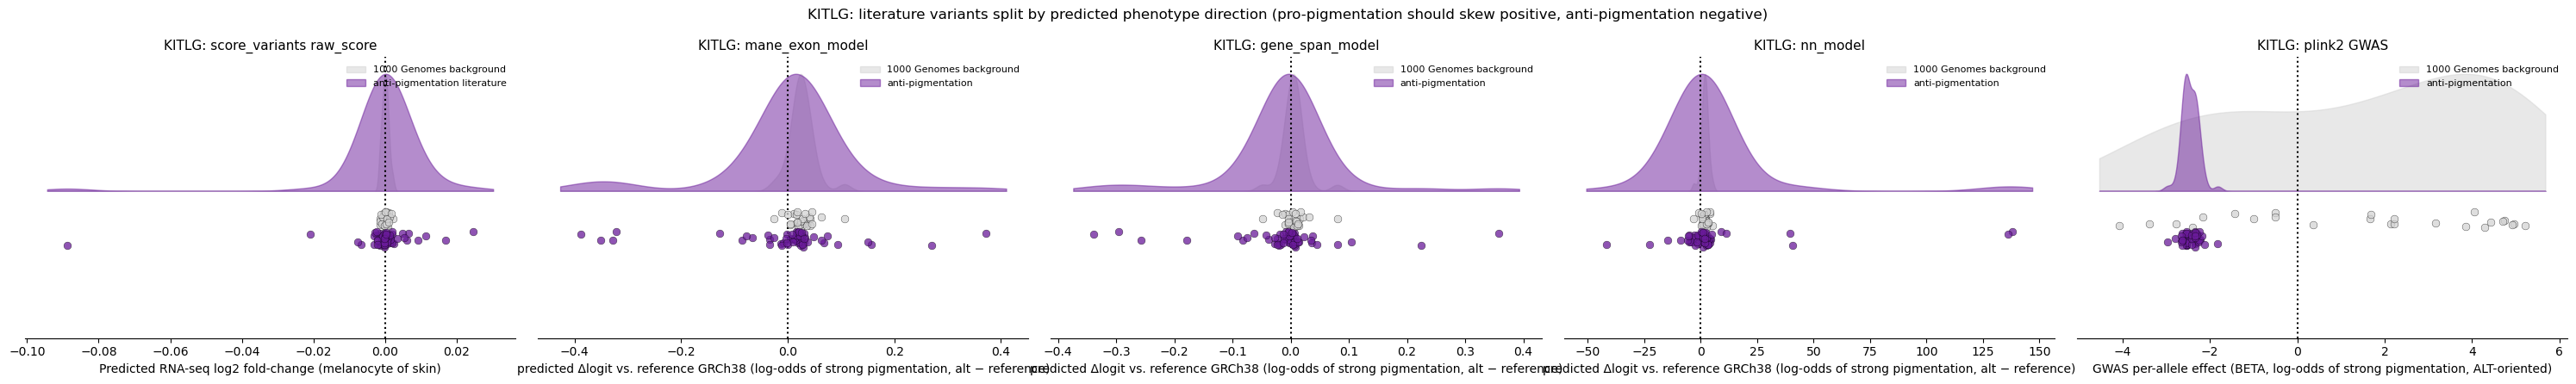

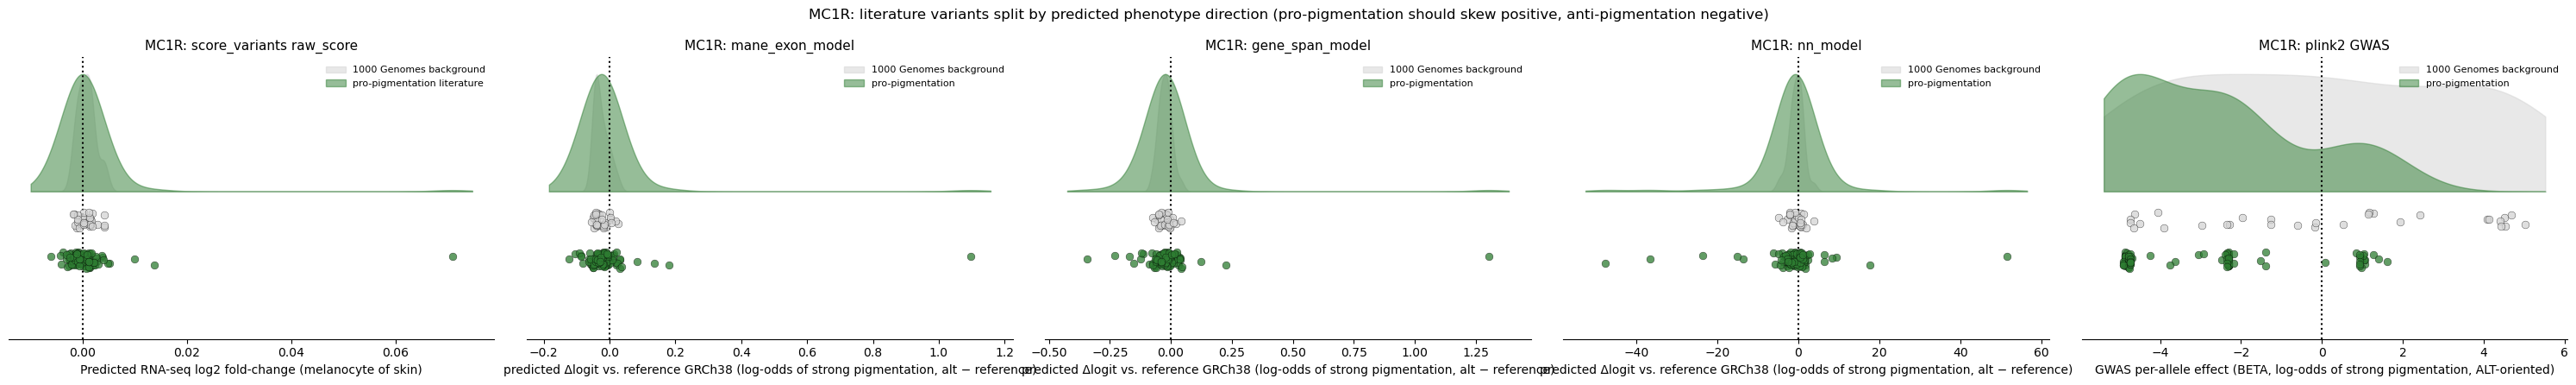

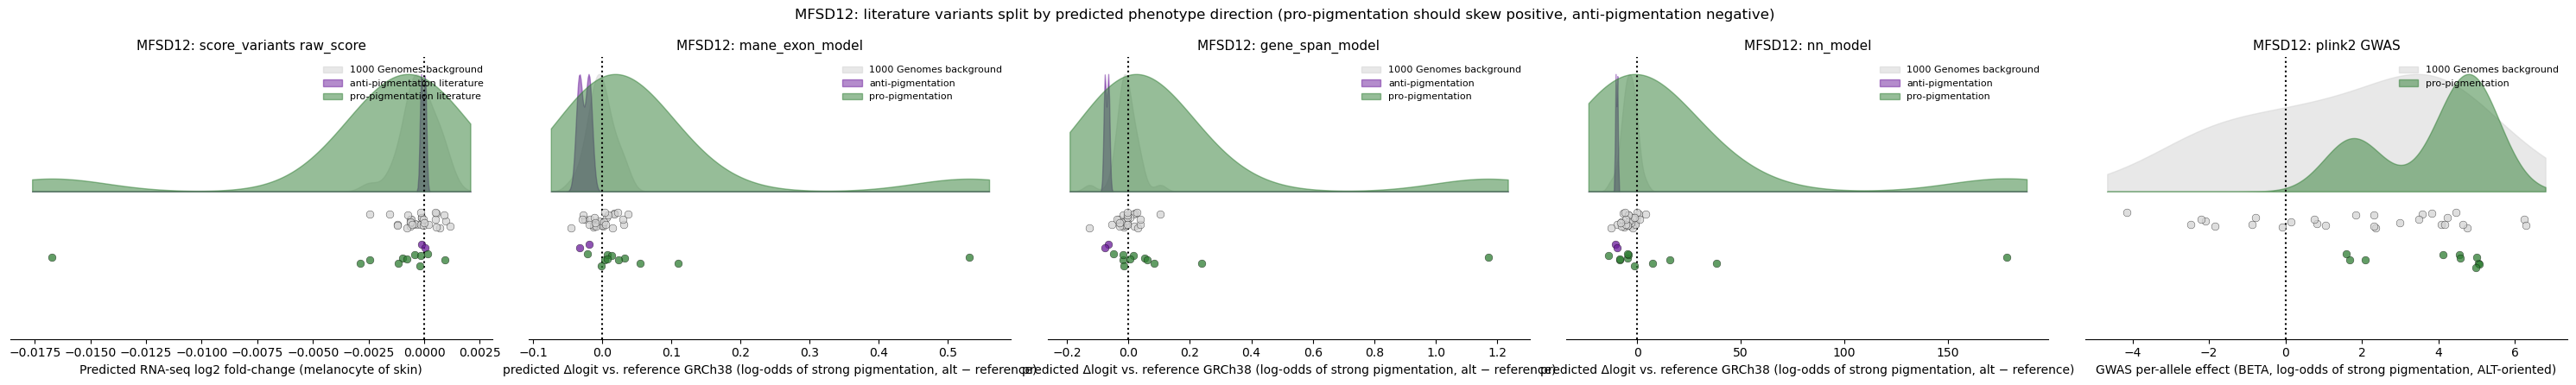

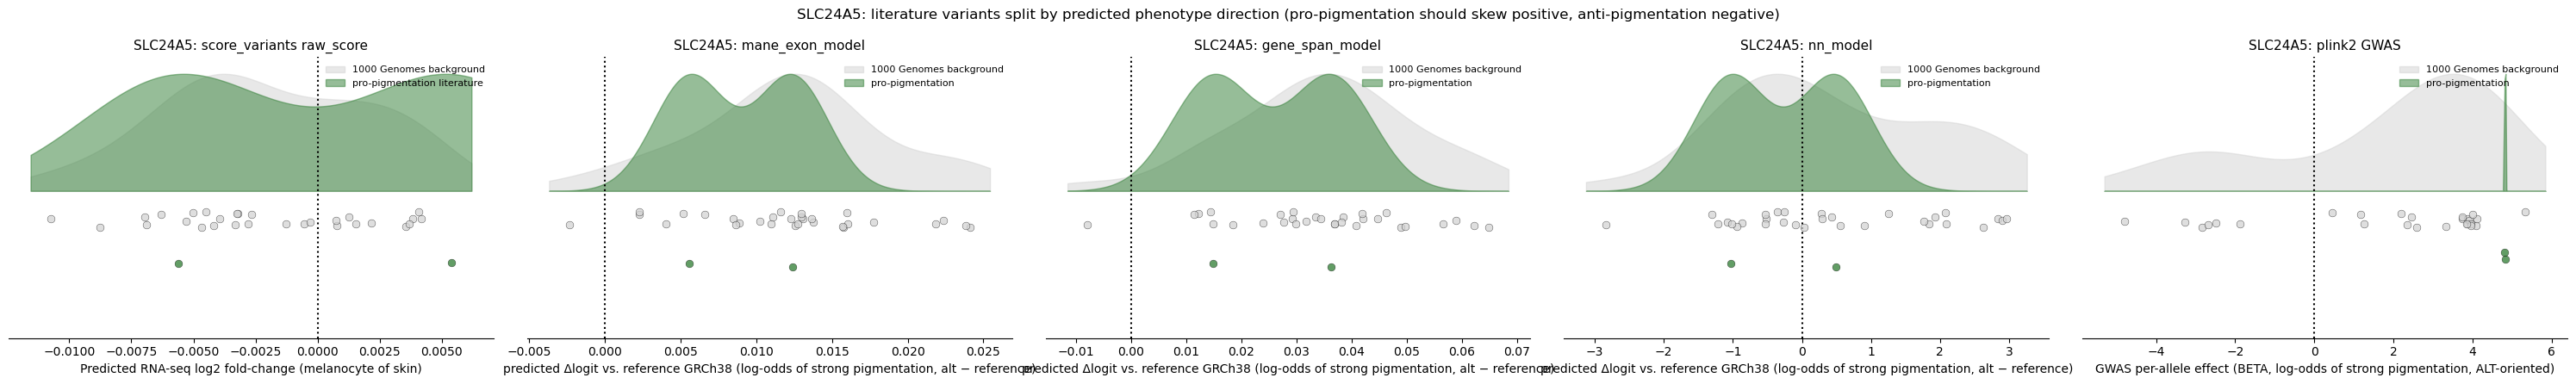

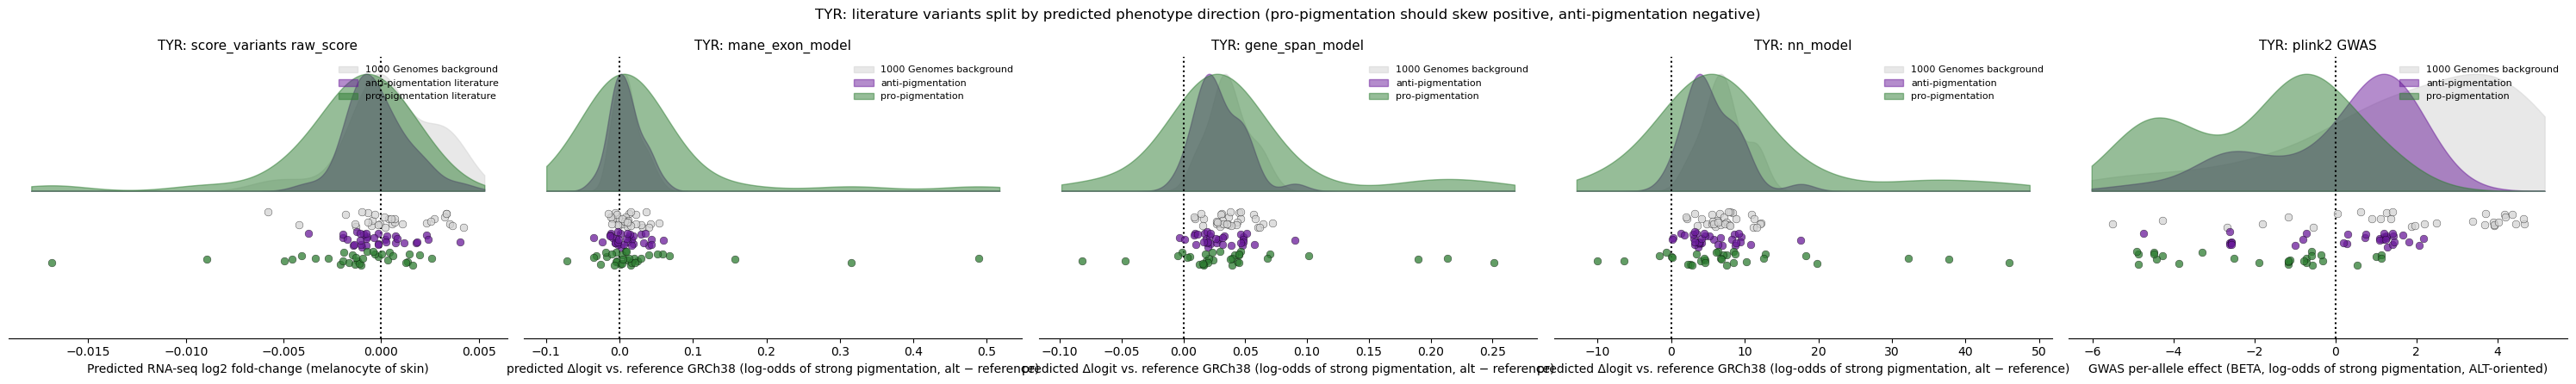

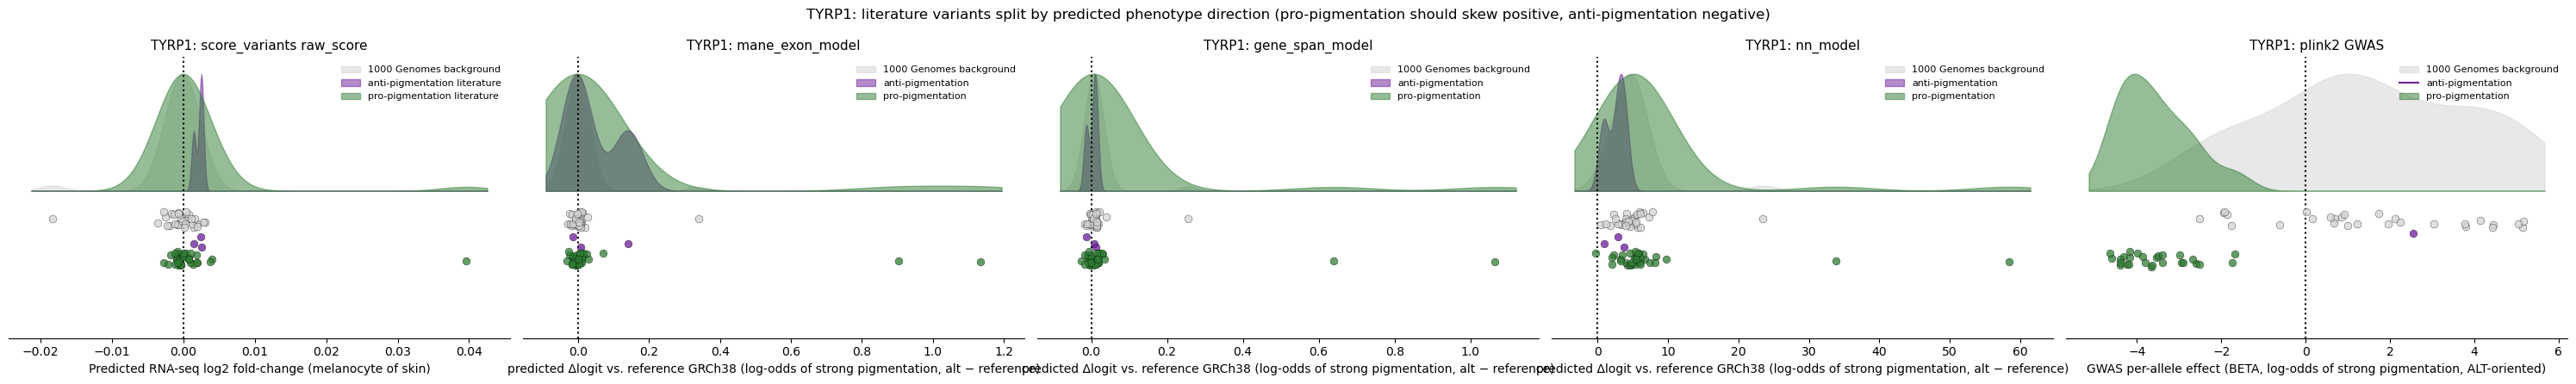

In [12]:
PRO_COLOR = "#2E7D32"    # green: pro-pigmentation literature variant
ANTI_COLOR = "#6A1B9A"   # purple: anti-pigmentation literature variant
BG_COLOR = "lightgray"

for gene, results in rain_plot_results.items():
    lit_score, bg_score = results["lit_score"], results["bg_score"]
    logit_df, bg_logit_df = results["logit_df"], results["bg_logit_df"]

    fig, axes = plt.subplots(1, 5, figsize=(30, 4.5))

    rain_density_plot(
        axes[0],
        [
            ("1000 Genomes background", bg_score["raw_score"].to_numpy(), BG_COLOR),
            ("anti-pigmentation literature",
             lit_score.loc[lit_score["phenotype_direction"] == "anti-pigmentation", "raw_score"].to_numpy(), ANTI_COLOR),
            ("pro-pigmentation literature",
             lit_score.loc[lit_score["phenotype_direction"] == "pro-pigmentation", "raw_score"].to_numpy(), PRO_COLOR),
        ],
        title=f"{gene}: score_variants raw_score",
        xlabel="Predicted RNA-seq log2 fold-change (melanocyte of skin)",
    )
    for ax, col, model_title, xlabel in zip(
        axes[1:],
        ["mane_exon_delta_logit", "gene_span_delta_logit", "nn_delta_logit", "gwas_beta"],
        ["mane_exon_model", "gene_span_model", "nn_model", "plink2 GWAS"],
        [
            "predicted Δlogit vs. reference GRCh38 (log-odds of strong pigmentation, alt − reference)",
            "predicted Δlogit vs. reference GRCh38 (log-odds of strong pigmentation, alt − reference)",
            "predicted Δlogit vs. reference GRCh38 (log-odds of strong pigmentation, alt − reference)",
            "GWAS per-allele effect (BETA, log-odds of strong pigmentation, ALT-oriented)",
        ],
    ):
        rain_density_plot(
            ax,
            [
                ("1000 Genomes background", bg_logit_df[col].dropna().to_numpy(), BG_COLOR),
                ("anti-pigmentation",
                 logit_df.loc[logit_df["phenotype_direction"] == "anti-pigmentation", col].dropna().to_numpy(), ANTI_COLOR),
                ("pro-pigmentation",
                 logit_df.loc[logit_df["phenotype_direction"] == "pro-pigmentation", col].dropna().to_numpy(), PRO_COLOR),
            ],
            title=f"{gene}: {model_title}",
            xlabel=xlabel,
        )
    fig.suptitle(
        f"{gene}: literature variants split by predicted phenotype direction "
        "(pro-pigmentation should skew positive, anti-pigmentation negative)",
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()


## Does AlphaGenome's predicted direction agree with GTEx's known direction? (all genes)

Every section above used AlphaGenome's own predictions as ground truth. This section instead
checks the pipeline against an **independent** measurement: for every gene, GTEx skin-tissue
eQTLs give each literature variant a signed, real-world direction of effect on expression
(`known_direction`, `nes` sign -- see notebook 1's VEP section and
`notebooks/utils/literature_variants.py`). AlphaGenome's `score_variants` independently predicts
its own signed direction (`predicted_direction`, `raw_score` sign, melanocyte-of-skin RNA-seq).

`agree = (predicted_direction == known_direction)` per variant is a genuine concordance check
between the pipeline's predictions and known biology -- not just a demonstration that the
pipeline runs. Genes with zero significant skin eQTLs in GTEx (confirmed for
`SLC45A2`/`DDB1`/`EDAR`/`HERC2`/`TCHH` at the time this was written) are skipped, not silently
dropped -- reported explicitly below.


In [13]:
TOP_N_LITERATURE_VARIANTS_PER_GENE = 100

literature_by_gene = literature_variants.get_literature_variants_all_genes(
    GENES, windows_df, ctx.ANNOTATIONS_CACHE_DIR, top_n=TOP_N_LITERATURE_VARIANTS_PER_GENE,
)
for gene in GENES:
    n = len(literature_by_gene[gene])
    print(f"{gene}: {n} GTEx skin-eQTL literature variant(s)" + (" -- skipping below" if n == 0 else ""))


MC1R: 100 GTEx skin-eQTL literature variant(s)
TYRP1: 35 GTEx skin-eQTL literature variant(s)
TYR: 64 GTEx skin-eQTL literature variant(s)
SLC45A2: 0 GTEx skin-eQTL literature variant(s) -- skipping below
MFSD12: 13 GTEx skin-eQTL literature variant(s)
OCA2: 20 GTEx skin-eQTL literature variant(s)
HERC2: 0 GTEx skin-eQTL literature variant(s) -- skipping below
SLC24A5: 2 GTEx skin-eQTL literature variant(s)
DDB1: 0 GTEx skin-eQTL literature variant(s) -- skipping below
KITLG: 59 GTEx skin-eQTL literature variant(s)
ASIP: 65 GTEx skin-eQTL literature variant(s)


In [14]:
concordance_rows = []
for gene in GENES:
    lit_df = literature_by_gene[gene]
    if lit_df.empty:
        continue

    variant_objs = [genome.Variant.from_str(v) for v in lit_df["variant"]]
    scored = score_variants_rna(variant_objs, gene)
    raw_score_by_variant = {
        f"{v.chromosome}:{v.position}:{v.reference_bases}>{v.alternate_bases}": raw_score
        for v, raw_score in zip(scored["variant_id"], scored["raw_score"])
    }

    for _, lit_row in lit_df.iterrows():
        raw_score = raw_score_by_variant.get(lit_row["variant"])
        if raw_score is None:
            continue  # variant's own 500kb window didn't retain a gene_name match after tidy_scores
        predicted_direction = "enhance" if raw_score > 0 else "diminish"
        concordance_rows.append({
            "gene": gene,
            "variant": lit_row["variant"],
            "known_direction": lit_row["direction"],
            "nes": lit_row["nes"],
            "p_value": lit_row["p_value"],
            "raw_score": raw_score,
            "predicted_direction": predicted_direction,
            "agree": predicted_direction == lit_row["direction"],
        })

concordance_df = pd.DataFrame(concordance_rows)
print(f"Scored {len(concordance_df)} literature variant(s) across "
      f"{concordance_df['gene'].nunique()} gene(s) with GTEx skin eQTLs.")
concordance_df


  0%|          | 0/100 [00:00<?, ?it/s]

  1%|          | 1/100 [00:00<01:20,  1.23it/s]

  3%|▎         | 3/100 [00:01<00:48,  2.00it/s]

  4%|▍         | 4/100 [00:01<00:35,  2.70it/s]

  5%|▌         | 5/100 [00:02<00:44,  2.16it/s]

...

 98%|█████████▊| 64/65 [00:27<00:00,  2.59it/s]

100%|██████████| 65/65 [00:27<00:00,  2.37it/s]

100%|██████████| 65/65 [00:27<00:00,  2.35it/s]

Scored 357 literature variant(s) across 8 gene(s) with GTEx skin eQTLs.


,gene,variant,known_direction,nes,p_value,raw_score,predicted_direction,agree
0,MC1R,chr16:89913750:A>G,enhance,0.396056,1.605271e-27,-0.001297,diminish,False
1,MC1R,chr16:89909088:G>A,enhance,0.395801,1.716044e-27,0.001387,enhance,True
2,MC1R,chr16:89909147:G>C,enhance,0.395801,1.716044e-27,0.003838,enhance,True
3,MC1R,chr16:89909164:A>G,enhance,0.395801,1.716044e-27,0.000789,enhance,True
4,MC1R,chr16:89906663:G>A,enhance,0.394049,4.232801e-27,0.000690,enhance,True
...,...,...,...,...,...,...,...,...
352,ASIP,chr20:34259905:G>A,diminish,-0.104046,4.185820e-04,-0.002454,diminish,True
353,ASIP,chr20:34259961:A>G,diminish,-0.104046,4.185820e-04,-0.008110,diminish,True
354,ASIP,chr20:34158397:T>C,diminish,-0.115275,4.380378e-04,0.003745,enhance,False
355,ASIP,chr20:34100307:A>G,diminish,-0.113633,4.619872e-04,0.000476,enhance,False


In [15]:
overall_rate = concordance_df["agree"].mean()
print(f"Overall concordance (AlphaGenome predicted direction == GTEx known direction): "
      f"{overall_rate:.1%} ({concordance_df['agree'].sum()}/{len(concordance_df)})")
if abs(overall_rate - 0.5) < 0.05:
    print("WARNING: concordance is near chance (50%) -- check for a sign-convention bug "
          "before treating this as a weak biological result.")

per_gene_summary = (
    concordance_df.groupby("gene")["agree"]
    .agg(n_variants="count", concordant="sum")
    .assign(concordance_rate=lambda d: d["concordant"] / d["n_variants"])
    .reindex(GENES)
)
per_gene_summary


Overall concordance (AlphaGenome predicted direction == GTEx known direction): 52.4% (187/357)


,n_variants,concordant,concordance_rate
gene,,,
MC1R,100.0,52.0,0.520000
TYRP1,35.0,21.0,0.600000
TYR,64.0,34.0,0.531250
SLC45A2,NaN,NaN,NaN
MFSD12,13.0,10.0,0.769231
OCA2,19.0,6.0,0.315789
HERC2,NaN,NaN,NaN
SLC24A5,2.0,1.0,0.500000
DDB1,NaN,NaN,NaN


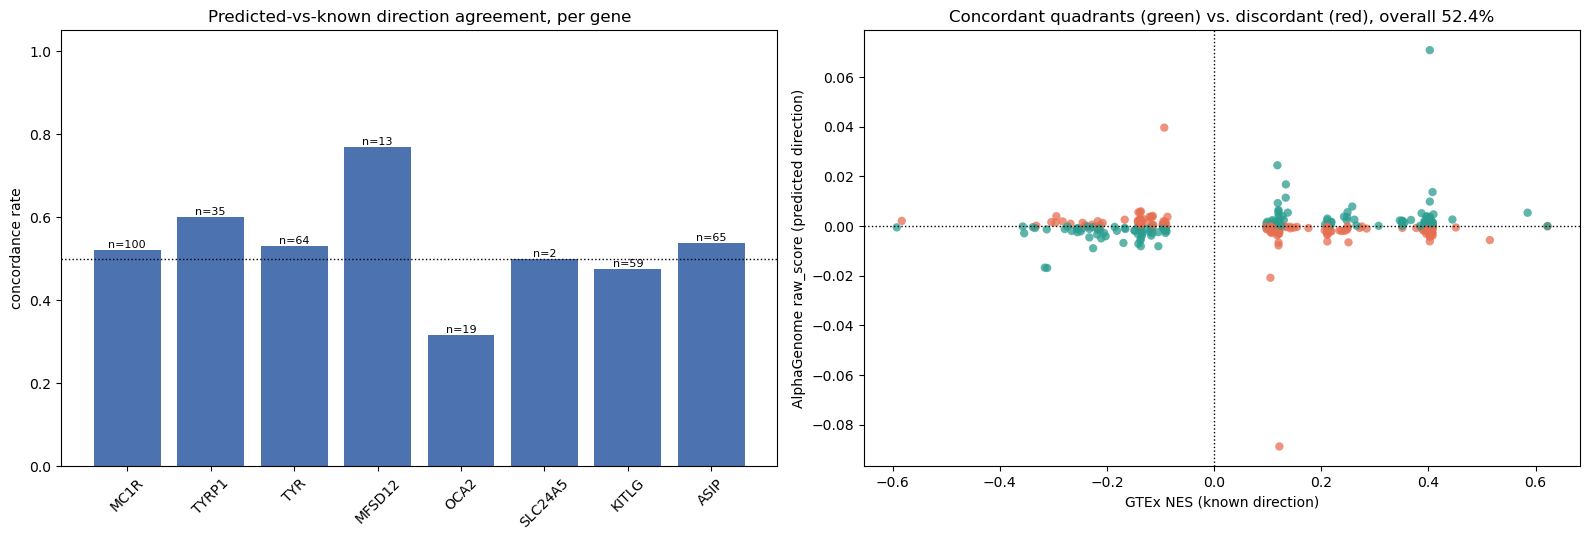

In [16]:
fig, (ax_bar, ax_scatter) = plt.subplots(1, 2, figsize=(16, 5.5))

plotted = per_gene_summary.dropna()
ax_bar.bar(plotted.index, plotted["concordance_rate"], color="#4C72B0")
for gene, row in plotted.iterrows():
    ax_bar.annotate(f"n={int(row['n_variants'])}", (gene, row["concordance_rate"]),
                     ha="center", va="bottom", fontsize=8)
ax_bar.axhline(0.5, color="black", linestyle=":", linewidth=1)
ax_bar.set_ylim(0, 1.05)
ax_bar.set_ylabel("concordance rate")
ax_bar.set_title("Predicted-vs-known direction agreement, per gene")
ax_bar.tick_params(axis="x", rotation=45)

colors = concordance_df["agree"].map({True: "#2A9D8F", False: "#E76F51"})
ax_scatter.scatter(concordance_df["nes"], concordance_df["raw_score"], c=colors, alpha=0.75, edgecolor="none")
ax_scatter.axhline(0, color="black", linestyle=":", linewidth=1)
ax_scatter.axvline(0, color="black", linestyle=":", linewidth=1)
ax_scatter.set_xlabel("GTEx NES (known direction)")
ax_scatter.set_ylabel("AlphaGenome raw_score (predicted direction)")
ax_scatter.set_title(f"Concordant quadrants (green) vs. discordant (red), overall {overall_rate:.1%}")

plt.tight_layout()
plt.show()
